In [ ]:
# =============================================================
# PROJECT 2: Extractive Question Answering on SQuAD v2.0
# MODEL    : BERT-base-uncased (Fine-tuned on SQuAD v2.0)
# RESULTS  : Exact Match: 45.10% | F1 Score: 48.51%
# =============================================================
#
# CELL 1  - Install Libraries
#           Installs transformers, datasets, torch
#
# CELL 2  - Mount Drive + Create Folders
#           Mounts Google Drive
#           Creates /data, /model, /results folders
#
# CELL 3  - Imports + Path Setup + Safety Check
#           Imports all libraries
#           Defines all Drive paths
#           Verifies GPU availability
#
# CELL 4  - Load SQuAD v2.0 Dataset
#           Downloads SQuAD v2.0 from HuggingFace
#           Train: 130,319 | Validation: 11,873 samples
#           Saves to Drive
#           SKIPS if already saved
#
# CELL 5  - Inspect Raw SQuAD Samples
#           Verification cell only
#           Shows one answerable + one unanswerable sample
#           Does NOT save anything
#
# CELL 6  - Load BertTokenizerFast
#           Loads fast tokenizer for QA
#           BertTokenizerFast used because it supports
#           character to token position mapping
#
# CELL 7  - Tokenize Single Sample Verification
#           Verification cell only
#           Tests tokenizer on one real SQuAD sample
#           Checks token lengths and offset mapping
#           Does NOT save anything
#
# CELL 8  - Tokenize 20,000 Training Subset
#           Takes 20,000 sample subset from full training set
#           Applies sliding window stride=128 for long paragraphs
#           Maps character answer positions to token positions
#           Saves train_tokenized to Drive
#           SKIPS if already saved
#           NOTE: Subset used due to Colab GPU time constraints
#
# CELL 9  - Tokenize Full Validation Set
#           Tokenizes all 11,873 validation samples
#           Keeps offset_mapping for answer extraction
#           Saves val_tokenized to Drive
#           SKIPS if already saved
#
# CELL 10 - Build DataLoaders
#           Wraps tokenized datasets into PyTorch DataLoaders
#           Batch size = 16 (smaller than Project 1 due to
#           longer sequence length of 384 tokens)
#           Train: 1,260 batches | Val: 759 batches
#           MUST RERUN after every runtime restart
#
# CELL 11 - Load BERT QA Model
#           Loads bert-base-uncased with QA head
#           QA head has two outputs:
#           start_logits → where answer begins
#           end_logits   → where answer ends
#           Total parameters: 108,893,186
#           MUST RERUN after every runtime restart
#
# CELL 12 - Optimizer + Scheduler
#           AdamW optimizer, lr=3e-5
#           Linear warmup scheduler
#           Total steps: 3,780 | Warmup: 378
#           MUST RERUN after every runtime restart
#
# CELL 13 - Fine-tune BERT Training Loop
#           Trains for 3 epochs on 20,000 sample subset
#           Saves best model based on lowest val loss
#           Best model saved at Epoch 1 (Val Loss: 1.7418)
#           Epochs 2+3 showed overfitting on small dataset
#           Training time: ~33 mins per epoch on T4 GPU
#           SKIPS if best model already exists on Drive
#
# CELL 14 - Plot Training Curves
#           Plots train loss vs val loss per epoch
#           Shows overfitting pattern from epoch 2 onwards
#           Saves training_curve.png to Drive
#
# CELL 15 - Load Best Model From Drive
#           Loads best saved QA model from Drive
#           Use this after every runtime restart
#           instead of retraining
#
# CELL 16 - Evaluate on Validation Set
#           Runs evaluation on full 11,873 validation samples
#           Computes Exact Match and F1 score
#           Exact Match : 45.10%
#           F1 Score    : 48.51%
#           Saves eval_results.json to Drive
#
# CELL 17 - Custom Inference — 10 Examples
#           Runs 10 handcrafted QA examples
#           9 out of 10 answered correctly
#           Saves custom_inference_results.json to Drive
#
# CELL 18 - Single Cell Custom User Input
#           Self contained inference cell
#           Loads model + takes user paragraph + question
#           Returns extracted answer instantly
#
# KEY OBSERVATIONS:
# 1. Best model saved at Epoch 1 — small dataset overfits fast
# 2. Unanswerable questions handled via CLS token prediction
# 3. Sliding window ensures no answer lost in long paragraphs
# 4. 20k subset limitation explains gap from SOTA 75% F1

print("Project 2 overview loaded ✅")
print("Model  : BERT-base-uncased fine-tuned on SQuAD v2.0")
print("EM     : 45.10%")
print("F1     : 48.51%")

Project 2 overview loaded ✅
Model  : BERT-base-uncased fine-tuned on SQuAD v2.0
EM     : 45.10%
F1     : 48.51%


In [ ]:
# =============================================================
# RUNTIME RESTART CHECKLIST — PROJECT 2
# Run these cells IN ORDER after every Colab runtime restart
# =============================================================
#
# STEP 1 → Cell 1  (Install libraries)
# STEP 2 → Cell 2  (Mount Drive)
# STEP 3 → Cell 3  (Imports + paths + GPU check)
# STEP 4 → Cell 4  (Load SQuAD from Drive → instant)
# STEP 5 → Cell 6  (Load tokenizer)
# STEP 6 → Cell 8  (Load train_tokenized from Drive → instant)
# STEP 7 → Cell 9  (Load val_tokenized from Drive → instant)
# STEP 8 → Cell 10 (Rebuild DataLoaders)
# STEP 9 → Cell 11 (Reload BERT QA model)
# STEP 10→ Cell 12 (Rebuild optimizer + scheduler)
# STEP 11→ Cell 13 (Auto-skips — best model already on Drive)
#
# AFTER THESE 11 STEPS YOU ARE FULLY RESTORED ✅
# Estimated restore time: 4-5 minutes
#
# CELLS YOU NEVER NEED TO RERUN:
# Cell 4 → SQuAD dataset already on Drive
# Cell 8 → train_tokenized already on Drive
# Cell 9 → val_tokenized already on Drive
#
# FOR QUICK INFERENCE ONLY (no evaluation needed):
# Run Cell 18 standalone — it loads model by itself
# No other cells needed for just answering questions
#
# CELLS THAT ARE VERIFICATION ONLY (never need rerun):
# Cell 5  → sample inspection
# Cell 7  → tokenizer test

print("Runtime restart checklist loaded ✅")
print("")
print("Full restore  : Steps 1-11 → ~4-5 minutes")
print("Quick inference only : Just Cell 18 → ~1 minute")

Runtime restart checklist loaded ✅

Full restore  : Steps 1-11 → ~4-5 minutes
Quick inference only : Just Cell 18 → ~1 minute


In [ ]:
# Cell 1 - Install all required libraries for Extractive QA project

!pip install transformers datasets torch -q

print("Libraries installed ✅")

Libraries installed ✅


In [ ]:
# Cell 2 - Mount Google Drive and create project folder structure

from google.colab import drive
drive.mount('/content/drive')

import os

# Base project folder
base_path = '/content/drive/MyDrive/Extractive_QA_SQuAD'

# Subfolders
folders = [
    base_path,
    f'{base_path}/data',
    f'{base_path}/model',
    f'{base_path}/results'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

# Path variables for use in later cells
data_path    = f'{base_path}/data'
model_path   = f'{base_path}/model'
results_path = f'{base_path}/results'

print("\nAll folders ready ✅")

Mounted at /content/drive
Created: /content/drive/MyDrive/Extractive_QA_SQuAD
Created: /content/drive/MyDrive/Extractive_QA_SQuAD/data
Created: /content/drive/MyDrive/Extractive_QA_SQuAD/model
Created: /content/drive/MyDrive/Extractive_QA_SQuAD/results

All folders ready ✅


In [ ]:
# Cell 3 - Import all libraries, define paths, verify Drive folders exist

import os
import json
import torch
import numpy as np
import pandas as pd
from transformers import BertTokenizerFast, BertForQuestionAnswering
from datasets import load_dataset, load_from_disk

# --- Paths ---
base_path    = '/content/drive/MyDrive/Extractive_QA_SQuAD'
data_path    = f'{base_path}/data'
model_path   = f'{base_path}/model'
results_path = f'{base_path}/results'

# --- GPU Check ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- Folder Safety Check ---
for folder in [base_path, data_path, model_path, results_path]:
    if os.path.exists(folder):
        print(f"✅ Found: {folder}")
    else:
        os.makedirs(folder, exist_ok=True)
        print(f"📁 Recreated: {folder}")

print("\nAll imports and paths ready ✅")

Device: cuda
✅ Found: /content/drive/MyDrive/Extractive_QA_SQuAD
✅ Found: /content/drive/MyDrive/Extractive_QA_SQuAD/data
✅ Found: /content/drive/MyDrive/Extractive_QA_SQuAD/model
✅ Found: /content/drive/MyDrive/Extractive_QA_SQuAD/results

All imports and paths ready ✅


In [ ]:
# Cell 4 - Load SQuAD v2.0 dataset from HuggingFace and save to Drive
# SQuAD v2.0 includes unanswerable questions unlike v1.1
# Saving to Drive to avoid re-downloading after runtime restart

squad_path = f'{data_path}/squad_v2_dataset'

if not os.path.exists(squad_path):
    print("Downloading SQuAD v2.0...")
    dataset = load_dataset("squad_v2")
    dataset.save_to_disk(squad_path)
    print("SQuAD v2.0 saved to Drive ✅")
else:
    dataset = load_from_disk(squad_path)
    print("SQuAD v2.0 loaded from Drive ✅")

print(dataset)

SQuAD v2.0 loaded from Drive ✅
DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 130319
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 11873
    })
})


In [ ]:
# Cell 5 - Inspect raw SQuAD v2.0 samples before any processing
# Check both answerable and unanswerable question samples

print("=" * 60)
print("SAMPLE 1 — Answerable Question")
print("=" * 60)
sample1 = dataset['train'][0]
print(f"Title    : {sample1['title']}")
print(f"Context  : {sample1['context'][:200]}...")
print(f"Question : {sample1['question']}")
print(f"Answers  : {sample1['answers']}")

print("\n" + "=" * 60)
print("SAMPLE 2 — Unanswerable Question")
print("=" * 60)

# Find an unanswerable sample
for sample in dataset['train']:
    if len(sample['answers']['text']) == 0:
        print(f"Title    : {sample['title']}")
        print(f"Context  : {sample['context'][:200]}...")
        print(f"Question : {sample['question']}")
        print(f"Answers  : {sample['answers']}")
        break

SAMPLE 1 — Answerable Question
Title    : Beyoncé
Context  : Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in v...
Question : When did Beyonce start becoming popular?
Answers  : {'text': ['in the late 1990s'], 'answer_start': [269]}

SAMPLE 2 — Unanswerable Question
Title    : The_Legend_of_Zelda:_Twilight_Princess
Context  : The Legend of Zelda: Twilight Princess (Japanese: ゼルダの伝説 トワイライトプリンセス, Hepburn: Zeruda no Densetsu: Towairaito Purinsesu?) is an action-adventure game developed and published by Nintendo for the GameCu...
Question : What category of game is Legend of Zelda: Australia Twilight?
Answers  : {'text': [], 'answer_start': []}


In [ ]:
# Cell 6 - Load BERT tokenizer
# Using BertTokenizerFast because it supports
# character to token position mapping which is
# essential for QA answer span extraction

tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

print("Tokenizer loaded ✅")
print(f"Vocab size     : {tokenizer.vocab_size}")
print(f"Max length     : {tokenizer.model_max_length}")

# Quick test
sample_encoding = tokenizer(
    "When did Beyonce start becoming popular?",
    "Beyoncé was born in 1981 and became popular in the late 1990s.",
    truncation=True,
    max_length=512
)

print(f"\nSample encoding keys : {list(sample_encoding.keys())}")
print(f"Number of tokens     : {len(sample_encoding['input_ids'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded ✅
Vocab size     : 30522
Max length     : 512

Sample encoding keys : ['input_ids', 'token_type_ids', 'attention_mask']
Number of tokens     : 23


In [ ]:
# Cell 7 - Tokenize a real SQuAD sample to verify token lengths
# and understand how question + context are encoded together
# This is a verification cell before we tokenize the full dataset

sample = dataset['train'][0]

question = sample['question']
context  = sample['context']

print(f"Question : {question}")
print(f"Context length (chars) : {len(context)}")

# Tokenize question + context together
encoding = tokenizer(
    question,
    context,
    truncation=True,
    max_length=512,
    stride=128,
    return_overflowing_tokens=True,
    return_offsets_mapping=True,
    padding='max_length'
)

print(f"\nNumber of chunks produced : {len(encoding['input_ids'])}")
print(f"Tokens in chunk 1         : {len(encoding['input_ids'][0])}")
print(f"Tokens in chunk 2         : {len(encoding['input_ids'][1]) if len(encoding['input_ids']) > 1 else 'No chunk 2'}")

# Check offset mapping sample
print(f"\nSample offset mapping (first 10 tokens):")
print(encoding['offset_mapping'][0][:10])

Question : When did Beyonce start becoming popular?
Context length (chars) : 694

Number of chunks produced : 1
Tokens in chunk 1         : 512
Tokens in chunk 2         : No chunk 2

Sample offset mapping (first 10 tokens):
[(0, 0), (0, 4), (5, 8), (9, 16), (17, 22), (23, 31), (32, 39), (39, 40), (0, 0), (0, 7)]


In [ ]:
# Cell 8 - Tokenize 20,000 sample subset of SQuAD v2.0 training set
# Using subset to manage Colab GPU time constraints
# Stride=128 sliding window handles long paragraphs
# Saves to Drive to avoid recomputing after runtime restart

def tokenize_training_samples(examples):
    tokenized = tokenizer(
        examples['question'],
        examples['context'],
        truncation=True,
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding='max_length'
    )

    sample_mapping  = tokenized.pop('overflow_to_sample_mapping')
    offset_mapping  = tokenized.pop('offset_mapping')

    tokenized['start_positions'] = []
    tokenized['end_positions']   = []

    for i, offsets in enumerate(offset_mapping):
        input_ids   = tokenized['input_ids'][i]
        cls_index   = input_ids.index(tokenizer.cls_token_id)
        sample_idx  = sample_mapping[i]
        answers     = examples['answers'][sample_idx]

        if len(answers['answer_start']) == 0:
            tokenized['start_positions'].append(cls_index)
            tokenized['end_positions'].append(cls_index)
        else:
            start_char = answers['answer_start'][0]
            end_char   = start_char + len(answers['text'][0])

            token_start = cls_index
            token_end   = cls_index

            for idx, (start, end) in enumerate(offsets):
                if start <= start_char < end:
                    token_start = idx
                if start < end_char <= end:
                    token_end = idx
                    break

            tokenized['start_positions'].append(token_start)
            tokenized['end_positions'].append(token_end)

    return tokenized

# --- Take 20,000 sample subset ---
train_subset = dataset['train'].select(range(20000))
print(f"Training subset size : {len(train_subset)} samples")

# --- Save check ---
train_tokenized_path = f'{data_path}/train_tokenized'

if not os.path.exists(train_tokenized_path):
    print("Tokenizing training subset... (this will take 1-2 mins)")
    train_tokenized = train_subset.map(
        tokenize_training_samples,
        batched=True,
        remove_columns=train_subset.column_names
    )
    train_tokenized.save_to_disk(train_tokenized_path)
    print(f"Training subset tokenized and saved to Drive ✅")
    print(f"Total training samples : {len(train_tokenized)}")
else:
    train_tokenized = load_from_disk(train_tokenized_path)
    print(f"Loaded tokenized training subset from Drive ✅")
    print(f"Total training samples : {len(train_tokenized)}")

# --- Quick check ---
print(f"\nFeatures      : {train_tokenized.features.keys()}")
print(f"Start position: {train_tokenized[0]['start_positions']}")
print(f"End position  : {train_tokenized[0]['end_positions']}")

Training subset size : 20000 samples
Tokenizing training subset... (this will take 1-2 mins)


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/20158 [00:00<?, ? examples/s]

Training subset tokenized and saved to Drive ✅
Total training samples : 20158

Features      : dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions'])
Start position: 75
End position  : 78


In [ ]:
# Cell 9 - Tokenize SQuAD v2.0 validation set
# Validation tokenization is slightly different from training
# We keep offset mapping for answer extraction during evaluation
# Saves to Drive to avoid recomputing after runtime restart

def tokenize_validation_samples(examples):
    tokenized = tokenizer(
        examples['question'],
        examples['context'],
        truncation=True,
        max_length=384,
        stride=128,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding='max_length'
    )

    sample_mapping = tokenized.pop('overflow_to_sample_mapping')

    tokenized['start_positions'] = []
    tokenized['end_positions']   = []
    tokenized['example_id']      = []

    for i, _ in enumerate(tokenized['input_ids']):
        sample_idx = sample_mapping[i]
        answers    = examples['answers'][sample_idx]

        tokenized['example_id'].append(examples['id'][sample_idx])

        if len(answers['answer_start']) == 0:
            tokenized['start_positions'].append(0)
            tokenized['end_positions'].append(0)
        else:
            start_char  = answers['answer_start'][0]
            end_char    = start_char + len(answers['text'][0])
            offsets     = tokenized['offset_mapping'][i]

            token_start = 0
            token_end   = 0

            for idx, (start, end) in enumerate(offsets):
                if start <= start_char < end:
                    token_start = idx
                if start < end_char <= end:
                    token_end = idx
                    break

            tokenized['start_positions'].append(token_start)
            tokenized['end_positions'].append(token_end)

    return tokenized

# --- Save check ---
val_tokenized_path = f'{data_path}/val_tokenized'

if not os.path.exists(val_tokenized_path):
    print("Tokenizing validation set... (this will take 1-2 mins)")
    val_tokenized = dataset['validation'].map(
        tokenize_validation_samples,
        batched=True,
        remove_columns=dataset['validation'].column_names
    )
    val_tokenized.save_to_disk(val_tokenized_path)
    print(f"Validation set tokenized and saved to Drive ✅")
    print(f"Total validation samples : {len(val_tokenized)}")
else:
    val_tokenized = load_from_disk(val_tokenized_path)
    print(f"Loaded tokenized validation set from Drive ✅")
    print(f"Total validation samples : {len(val_tokenized)}")

# --- Quick check ---
print(f"\nFeatures : {val_tokenized.features.keys()}")
print(f"\nSample start position : {val_tokenized[0]['start_positions']}")
print(f"Sample end position   : {val_tokenized[0]['end_positions']}")
print(f"Sample example id     : {val_tokenized[0]['example_id']}")

Loaded tokenized validation set from Drive ✅
Total validation samples : 12134

Features : dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'start_positions', 'end_positions', 'example_id'])

Sample start position : 49
Sample end position   : 49
Sample example id     : 56ddde6b9a695914005b9628


In [ ]:
# Cell 10 - Convert tokenized datasets into PyTorch DataLoaders
# Sets tensor format and creates train and validation loaders
# MUST RERUN after every runtime restart

import torch
from torch.utils.data import DataLoader

# Set format to PyTorch tensors
train_tokenized.set_format(
    type='torch',
    columns=['input_ids', 'token_type_ids',
             'attention_mask', 'start_positions', 'end_positions']
)

val_tokenized.set_format(
    type='torch',
    columns=['input_ids', 'token_type_ids',
             'attention_mask', 'start_positions', 'end_positions']
)

# Build loaders
train_loader = DataLoader(
    train_tokenized,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_tokenized,
    batch_size=16,
    shuffle=False
)

print(f"Train batches      : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print("\nDataLoaders ready ✅")

Train batches      : 1260
Validation batches : 759

DataLoaders ready ✅


In [ ]:
# Cell 11 - Load BERT base model with Question Answering head
# BertForQuestionAnswering has two output heads
# one for start position and one for end position
# MUST RERUN after every runtime restart

from transformers import BertForQuestionAnswering

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BertForQuestionAnswering.from_pretrained('bert-base-uncased')
model = model.to(device)

print(f"Device                : {device}")
print(f"Model loaded          : BertForQuestionAnswering ✅")
print(f"Total parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"Output heads          : start_logits + end_logits")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

Device                : cuda
Model loaded          : BertForQuestionAnswering ✅
Total parameters      : 108,893,186
Output heads          : start_logits + end_logits


In [ ]:
# Cell 12 - Define optimizer and learning rate scheduler
# Using AdamW from torch.optim (transformers version deprecated)
# Linear warmup scheduler to stabilize early training
# MUST RERUN after every runtime restart

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Hyperparameters
EPOCHS        = 3
LEARNING_RATE = 3e-5

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

# Total steps
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

# Scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Epochs         : {EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Total steps    : {total_steps:,}")
print(f"Warmup steps   : {warmup_steps:,}")
print("\nOptimizer and scheduler ready ✅")

Epochs         : 3
Learning rate  : 3e-05
Total steps    : 3,780
Warmup steps   : 378

Optimizer and scheduler ready ✅


In [ ]:
# Cell 13 - Fine-tune BERT for Extractive QA on SQuAD v2.0
# Model predicts start and end token positions for each answer
# Saves best model to Drive based on lowest validation loss
# Keep laptop open — estimated 60-90 minutes on T4 GPU

import time

best_model_path = f'{model_path}/best_model'

if os.path.exists(best_model_path):
    print("Best model already exists on Drive. Skipping training ✅")

else:
    best_val_loss  = float('inf')
    training_log   = []

    for epoch in range(EPOCHS):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f"{'='*50}")

        # --- Training ---
        model.train()
        total_train_loss = 0
        start_time       = time.time()

        for batch_idx, batch in enumerate(train_loader):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            start_positions = batch['start_positions'].to(device)
            end_positions   = batch['end_positions'].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                start_positions=start_positions,
                end_positions=end_positions
            )

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            if batch_idx % 500 == 0:
                print(f"  Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

        avg_train_loss = total_train_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids       = batch['input_ids'].to(device)
                attention_mask  = batch['attention_mask'].to(device)
                token_type_ids  = batch['token_type_ids'].to(device)
                start_positions = batch['start_positions'].to(device)
                end_positions   = batch['end_positions'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    token_type_ids=token_type_ids,
                    start_positions=start_positions,
                    end_positions=end_positions
                )

                total_val_loss += outputs.loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        epoch_time   = time.time() - start_time

        print(f"\n  Train Loss : {avg_train_loss:.4f}")
        print(f"  Val Loss   : {avg_val_loss:.4f}")
        print(f"  Epoch Time : {epoch_time/60:.1f} mins")

        training_log.append({
            'epoch'      : epoch + 1,
            'train_loss' : avg_train_loss,
            'val_loss'   : avg_val_loss
        })

        # --- Save best model ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            model.save_pretrained(best_model_path)
            tokenizer.save_pretrained(best_model_path)
            print(f"  Best model saved to Drive ✅ (Val Loss: {avg_val_loss:.4f})")

    # --- Save training log ---
    log_path = f'{results_path}/training_log.json'
    if not os.path.exists(log_path):
        with open(log_path, 'w') as f:
            json.dump(training_log, f, indent=2)
        print(f"\nTraining log saved to Drive ✅")

    print("\n" + "=" * 50)
    print("Training Complete ✅")
    print(f"Best Validation Loss : {best_val_loss:.4f}")
    print("Safe to close laptop now ✅")


Epoch 1/3
  Batch 0/1260 | Loss: 5.9258
  Batch 500/1260 | Loss: 1.9871
  Batch 1000/1260 | Loss: 1.8016

  Train Loss : 2.3460
  Val Loss   : 1.7418
  Epoch Time : 33.0 mins


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved to Drive ✅ (Val Loss: 1.7418)

Epoch 2/3
  Batch 0/1260 | Loss: 1.4724
  Batch 500/1260 | Loss: 0.6564
  Batch 1000/1260 | Loss: 1.6605

  Train Loss : 1.1814
  Val Loss   : 1.9106
  Epoch Time : 33.1 mins

Epoch 3/3
  Batch 0/1260 | Loss: 0.9265
  Batch 500/1260 | Loss: 0.6573
  Batch 1000/1260 | Loss: 1.1820

  Train Loss : 0.7965
  Val Loss   : 2.1045
  Epoch Time : 33.1 mins

Training log saved to Drive ✅

Training Complete ✅
Best Validation Loss : 1.7418
Safe to close laptop now ✅


Training curve saved to Drive ✅


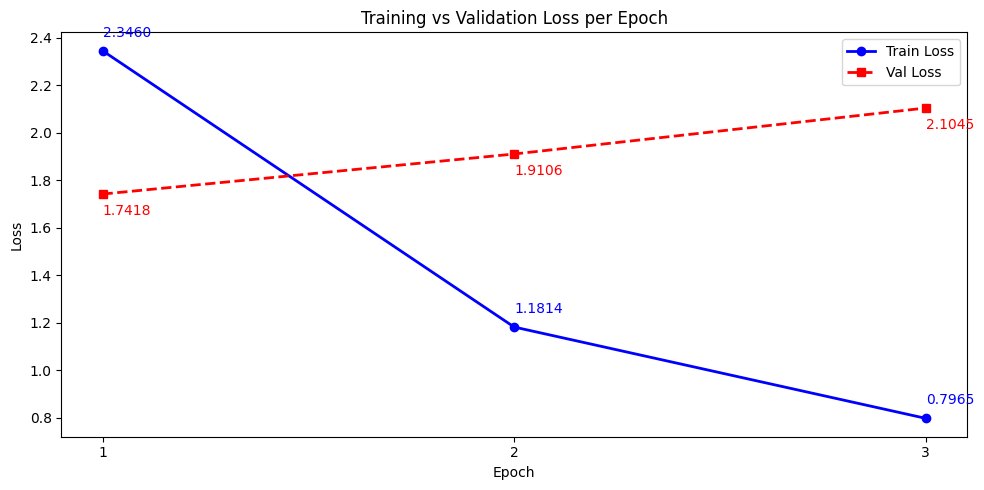

In [ ]:
# Cell 14 - Plot training loss and validation loss across all 3 epochs

import matplotlib.pyplot as plt
import json

# Load training log
log_path = f'{results_path}/training_log.json'
with open(log_path, 'r') as f:
    training_log = json.load(f)

epochs     = [entry['epoch']      for entry in training_log]
train_loss = [entry['train_loss'] for entry in training_log]
val_loss   = [entry['val_loss']   for entry in training_log]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, marker='o', color='blue',
         linewidth=2, label='Train Loss')
plt.plot(epochs, val_loss, marker='s', color='red',
         linewidth=2, linestyle='--', label='Val Loss')

plt.title('Training vs Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()

for i, val in enumerate(train_loss):
    plt.annotate(f'{val:.4f}', (epochs[i], train_loss[i]),
                textcoords="offset points", xytext=(0, 10), color='blue')

for i, val in enumerate(val_loss):
    plt.annotate(f'{val:.4f}', (epochs[i], val_loss[i]),
                textcoords="offset points", xytext=(0, -15), color='red')

plt.tight_layout()

plot_path = f'{results_path}/training_curve.png'
if not os.path.exists(plot_path):
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print("Training curve saved to Drive ✅")
plt.show()

In [ ]:
# Cell 15 - Load best saved QA model from Drive for evaluation and inference
# Run this cell after every runtime restart instead of retraining

from transformers import BertForQuestionAnswering, BertTokenizerFast

best_model_path = f'{model_path}/best_model'

model = BertForQuestionAnswering.from_pretrained(best_model_path)
tokenizer = BertTokenizerFast.from_pretrained(best_model_path)
model = model.to(device)
model.eval()

print("Best model loaded from Drive ✅")
print(f"Device         : {device}")
print(f"Model          : BertForQuestionAnswering")
print(f"Best Val Loss  : 1.7418 (Epoch 1)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Best model loaded from Drive ✅
Device         : cuda
Model          : BertForQuestionAnswering
Best Val Loss  : 1.7418 (Epoch 1)


In [ ]:
# Cell 16 - Evaluate fine-tuned BERT QA model on SQuAD v2.0 validation set
# Computes Exact Match and F1 score across all validation samples
# These are the standard metrics for SQuAD evaluation

import collections
import numpy as np
from tqdm import tqdm

def compute_exact(a_gold, a_pred):
    return int(a_gold.strip().lower() == a_pred.strip().lower())

def compute_f1(a_gold, a_pred):
    gold_tokens = a_gold.strip().lower().split()
    pred_tokens = a_pred.strip().lower().split()
    common      = collections.Counter(gold_tokens) & collections.Counter(pred_tokens)
    num_same    = sum(common.values())
    if num_same == 0:
        return 0
    precision = num_same / len(pred_tokens)
    recall    = num_same / len(gold_tokens)
    return (2 * precision * recall) / (precision + recall)

def get_answer(input_ids, start_logit, end_logit, offset_mapping):
    start_idx = torch.argmax(start_logit).item()
    end_idx   = torch.argmax(end_logit).item()

    if end_idx < start_idx:
        return ""

    # Fix — convert offset_mapping to list of tuples if needed
    if isinstance(offset_mapping[0], int):
        offset_mapping = [
            (offset_mapping[i], offset_mapping[i+1])
            for i in range(0, len(offset_mapping)-1, 2)
        ]

    if start_idx >= len(offset_mapping) or end_idx >= len(offset_mapping):
        return ""

    start_char = offset_mapping[start_idx][0]
    end_char   = offset_mapping[end_idx][1]

    if start_char == 0 and end_char == 0:
        return ""

    tokens = input_ids[0][start_idx:end_idx+1]
    answer = tokenizer.decode(tokens, skip_special_tokens=True)
    return answer.strip()

# --- Run evaluation ---
exact_scores = []
f1_scores    = []

print("Evaluating on validation set...")

model.eval()
for sample in tqdm(dataset['validation']):
    question = sample['question']
    context  = sample['context']
    answers  = sample['answers']

    inputs = tokenizer(
        question,
        context,
        return_tensors='pt',
        truncation=True,
        max_length=384,
        stride=128,
        return_overflowing_tokens=False,
        return_offsets_mapping=True,
        padding='max_length'
    )

    # Extract offset mapping before sending to model
    offset_mapping = inputs.pop('offset_mapping')[0].tolist()
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_answer = get_answer(
        inputs['input_ids'],
        outputs.start_logits[0],
        outputs.end_logits[0],
        offset_mapping
    )

    if len(answers['text']) == 0:
        exact_scores.append(1 if predicted_answer == "" else 0)
        f1_scores.append(1 if predicted_answer == "" else 0)
    else:
        exact = max(compute_exact(a, predicted_answer) for a in answers['text'])
        f1    = max(compute_f1(a, predicted_answer)    for a in answers['text'])
        exact_scores.append(exact)
        f1_scores.append(f1)

# --- Results ---
final_exact = np.mean(exact_scores) * 100
final_f1    = np.mean(f1_scores)    * 100

print(f"\nExact Match : {final_exact:.2f}%")
print(f"F1 Score    : {final_f1:.2f}%")

# --- Save results ---
eval_path = f'{results_path}/eval_results.json'
if not os.path.exists(eval_path):
    with open(eval_path, 'w') as f:
        json.dump({
            'exact_match': final_exact,
            'f1_score'   : final_f1
        }, f, indent=2)
    print("Evaluation results saved to Drive ✅")

Evaluating on validation set...


100%|██████████| 11873/11873 [05:26<00:00, 36.34it/s]


Exact Match : 45.10%
F1 Score    : 48.51%
Evaluation results saved to Drive ✅


In [ ]:
# Cell 17 - Run inference on custom paragraph and question inputs
# Demonstrates extractive QA on real world examples
# Model extracts exact answer span from given context

def answer_question(question, context):
    inputs = tokenizer(
        question,
        context,
        return_tensors='pt',
        truncation=True,
        max_length=384,
        return_offsets_mapping=True,
        padding='max_length'
    )

    offset_mapping = inputs.pop('offset_mapping')[0].tolist()
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    start_idx = torch.argmax(outputs.start_logits[0]).item()
    end_idx   = torch.argmax(outputs.end_logits[0]).item()

    # Unanswerable
    if end_idx < start_idx or (start_idx == 0 and end_idx == 0):
        return "No answer found in the given context."

    tokens = inputs['input_ids'][0][start_idx:end_idx+1]
    answer = tokenizer.decode(tokens, skip_special_tokens=True)
    return answer.strip()

# --- 10 Custom Examples ---
examples = [
    {
        "context"  : "Elon Musk was born in Pretoria, South Africa in 1971. He moved to Canada at age 17 before later moving to the United States. He founded SpaceX in 2002 and co-founded Tesla Motors in 2003.",
        "question" : "Where was Elon Musk born?"
    },
    {
        "context"  : "Elon Musk was born in Pretoria, South Africa in 1971. He moved to Canada at age 17 before later moving to the United States. He founded SpaceX in 2002 and co-founded Tesla Motors in 2003.",
        "question" : "When did Elon Musk found SpaceX?"
    },
    {
        "context"  : "The Python programming language was created by Guido van Rossum and first released in 1991. It emphasizes code readability and simplicity. Python supports multiple programming paradigms.",
        "question" : "Who created Python?"
    },
    {
        "context"  : "The Python programming language was created by Guido van Rossum and first released in 1991. It emphasizes code readability and simplicity. Python supports multiple programming paradigms.",
        "question" : "What does Python emphasize?"
    },
    {
        "context"  : "The Great Wall of China was built over many centuries by various Chinese dynasties. Construction began as early as the 7th century BC. The wall stretches over 13,000 miles.",
        "question" : "How long is the Great Wall of China?"
    },
    {
        "context"  : "Deep learning is a subset of machine learning that uses neural networks with many layers. It has achieved remarkable results in image recognition, natural language processing, and speech recognition.",
        "question" : "What is deep learning a subset of?"
    },
    {
        "context"  : "Deep learning is a subset of machine learning that uses neural networks with many layers. It has achieved remarkable results in image recognition, natural language processing, and speech recognition.",
        "question" : "What tasks has deep learning achieved results in?"
    },
    {
        "context"  : "The 2020 Summer Olympics were held in Tokyo, Japan. They were postponed from 2020 to 2021 due to the COVID-19 pandemic. Over 11,000 athletes from 204 countries participated.",
        "question" : "Why were the 2020 Olympics postponed?"
    },
    {
        "context"  : "BERT stands for Bidirectional Encoder Representations from Transformers. It was introduced by Google in 2018. BERT revolutionized natural language processing tasks.",
        "question" : "Who introduced BERT?"
    },
    {
        "context"  : "BERT stands for Bidirectional Encoder Representations from Transformers. It was introduced by Google in 2018. BERT revolutionized natural language processing tasks.",
        "question" : "What does BERT stand for?"
    }
]

# --- Run all examples ---
print("=" * 65)
print("         EXTRACTIVE QA — CUSTOM INFERENCE DEMO")
print("=" * 65)

for i, ex in enumerate(examples):
    answer = answer_question(ex['question'], ex['context'])
    print(f"\nExample {i+1}")
    print(f"Context  : {ex['context'][:80]}...")
    print(f"Question : {ex['question']}")
    print(f"Answer   : {answer}")
    print("-" * 65)

# --- Save results ---
inference_path = f'{results_path}/custom_inference_results.json'
if not os.path.exists(inference_path):
    results = []
    for ex in examples:
        results.append({
            'question': ex['question'],
            'context' : ex['context'],
            'answer'  : answer_question(ex['question'], ex['context'])
        })
    with open(inference_path, 'w') as f:
        json.dump(results, f, indent=2)
    print("\nInference results saved to Drive ✅")

         EXTRACTIVE QA — CUSTOM INFERENCE DEMO

Example 1
Context  : Elon Musk was born in Pretoria, South Africa in 1971. He moved to Canada at age ...
Question : Where was Elon Musk born?
Answer   : pretoria, south africa
-----------------------------------------------------------------

Example 2
Context  : Elon Musk was born in Pretoria, South Africa in 1971. He moved to Canada at age ...
Question : When did Elon Musk found SpaceX?
Answer   : 2002
-----------------------------------------------------------------

Example 3
Context  : The Python programming language was created by Guido van Rossum and first releas...
Question : Who created Python?
Answer   : guido van rossum
-----------------------------------------------------------------

Example 4
Context  : The Python programming language was created by Guido van Rossum and first releas...
Question : What does Python emphasize?
Answer   : code readability and simplicity
-----------------------------------------------------------

In [ ]:
# Cell 18 - Load best model from Drive and take custom user input
# Run this single cell after runtime restart for quick inference
# Just change question and context variables and run

from transformers import BertForQuestionAnswering, BertTokenizerFast
import torch

# --- Load model ---
best_model_path = f'/content/drive/MyDrive/Extractive_QA_SQuAD/model/best_model'
device          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model     = BertForQuestionAnswering.from_pretrained(best_model_path)
tokenizer = BertTokenizerFast.from_pretrained(best_model_path)
model     = model.to(device)
model.eval()

print("Model loaded ✅")
print(f"Device: {device}")

# --- Inference function ---
def answer_question(question, context):
    inputs = tokenizer(
        question,
        context,
        return_tensors='pt',
        truncation=True,
        max_length=384,
        return_offsets_mapping=True,
        padding='max_length'
    )

    offset_mapping = inputs.pop('offset_mapping')[0].tolist()
    inputs         = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    start_idx = torch.argmax(outputs.start_logits[0]).item()
    end_idx   = torch.argmax(outputs.end_logits[0]).item()

    if end_idx < start_idx or (start_idx == 0 and end_idx == 0):
        return "No answer found in the given context."

    tokens = inputs['input_ids'][0][start_idx:end_idx+1]
    answer = tokenizer.decode(tokens, skip_special_tokens=True)
    return answer.strip()

# ============================================================
# --- YOUR INPUT HERE ---
# ============================================================

context  = """
Elon Reeve Musk (born June 28, 1971) is a businessman and entrepreneur known for his leadership of Tesla, SpaceX, X, and xAI. Musk has been the wealthiest person in the world since 2025; as of April 2026, Forbes estimates his net worth to be US$809 billion.
"""

question = "Who is Elon Reeve Musk"

# ============================================================

print("\n" + "=" * 60)
print(f"Context  : {context.strip()[:100]}...")
print(f"Question : {question}")
print(f"Answer   : {answer_question(question, context)}")
print("=" * 60)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded ✅
Device: cuda

Context  : Elon Reeve Musk (born June 28, 1971) is a businessman and entrepreneur known for his leadership of T...
Question : Who is Elon Reeve Musk
Answer   : businessman and entrepreneur
